#Graph Neural Networks for Molecular Property Prediction
# Predicting Drug Solubility from Molecular Structure

 Pradip Palekar ,
 Institute: IIIT Delhi, M.Tech Computational Biology


STEP 1: Install Libraries

In [6]:
 !pip install torch torchvision
 !pip install torch-geometric
 !pip install rdkit-pypi
 !pip install deepchem
 !pip install matplotlib seaborn scikit-learn pandas numpy
 !pip install rdkit-pypi
 !pip install rdkit

ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi
ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 57.7 MB/s eta 0:00:00


STEP 2: Import Libraries

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_max_pool
from torch_geometric.data import Data, DataLoader
from torch_geometric.utils import from_smiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, AllChem
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")


All libraries imported!
PyTorch version: 2.10.0+cu128
CUDA available: True
Using: cuda


 STEP 3: Load ESOL Dataset (Drug Solubility)

In [8]:
# ESOL = Estimated SOLubility
# Real pharmaceutical dataset: 1,128 drug-like molecules
# Target: log solubility in mol/L (logS)
# This is a key ADMET property in drug discovery

print("\nLoading ESOL dataset...")


Loading ESOL dataset...


In [9]:
import deepchem as dc
tasks, datasets, transformers = dc.molnet.load_delaney(featurizer='Raw', splitter=None)
dataset = datasets[0]

# Build dataframe
smiles_list = dataset.ids
y_values = dataset.y.flatten()

df = pd.DataFrame({
    'smiles': smiles_list,
    'logS': y_values
})


wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


In [10]:
# Remove any invalid molecules
valid_mask = []
for smi in df['smiles']:
    mol = Chem.MolFromSmiles(smi)
    valid_mask.append(mol is not None)
df = df[valid_mask].reset_index(drop=True)

print(f"Dataset loaded: {len(df)} molecules")
print(f"Target: log Solubility (logS)")
print(f"logS range: {df['logS'].min():.2f} to {df['logS'].max():.2f}")
print(f"\nSample molecules:")
print(df.head(10).to_string(index=False))

Dataset loaded: 1128 molecules
Target: log Solubility (logS)
logS range: -4.08 to 2.21

Sample molecules:
                                                smiles      logS
OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O   1.088088
                                Cc1occc1C(=O)Nc2ccccc2 -0.119254
                                  CC(C)=CCCC(C)=CC(=O)  0.472487
                    c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43 -2.300105
                                               c1ccsc1  0.820851
                                        c2ccc1scnc1c2   0.739725
                    Clc1cc(Cl)c(c(Cl)c1)c2c(Cl)cccc2Cl -2.037640
                      CC12CCC3C(CCc4cc(O)ccc34)C2CCC1O -0.944828
        ClC4=C(Cl)C5(Cl)C3C1CC(C2OC12)C3C4(Cl)C5(Cl)Cl -1.546113
      COc5cc4OCC3Oc2c1CC(Oc1ccc2C(=O)C3c4cc5OC)C(C)=C  -0.653730


 STEP 4: Visualize Some Molecules


Visualizing sample molecules...


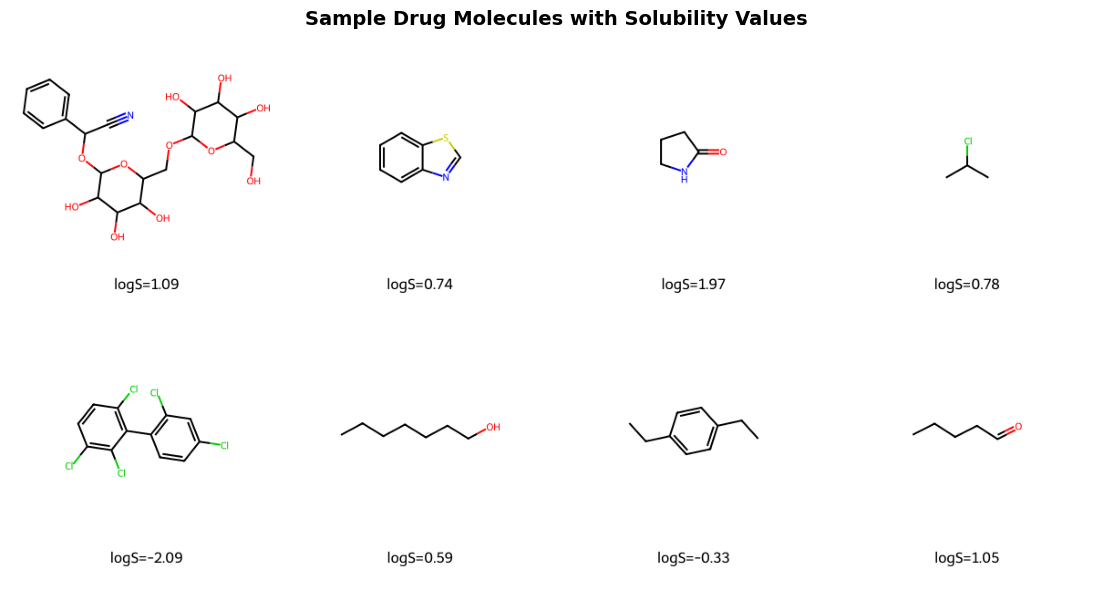

Saved sample_molecules.png


In [16]:
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw

print("\nVisualizing sample molecules...")

sample_mols = []
sample_labels = []

for idx in [0, 5, 10, 15, 20, 25, 30, 35]:

    if idx < len(df):

        smiles = df['smiles'].iloc[idx]

        mol = Chem.MolFromSmiles(smiles)

        if mol is not None:

            sample_mols.append(mol)

            sample_labels.append(
                f"logS={df['logS'].iloc[idx]:.2f}"
            )

if len(sample_mols) > 0:

    img = Draw.MolsToGridImage(
        sample_mols,
        molsPerRow=4,
        subImgSize=(300, 300),
        legends=sample_labels,
        returnPNG=False
    )

    img.save("sample_molecules.png")

    plt.figure(figsize=(12, 6))

    plt.imshow(img)

    plt.axis('off')

    plt.title(
        "Sample Drug Molecules with Solubility Values",
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.show()

    print("Saved sample_molecules.png")

else:

    print("No valid molecules found.")

STEP 5: Distribution of Solubility Values

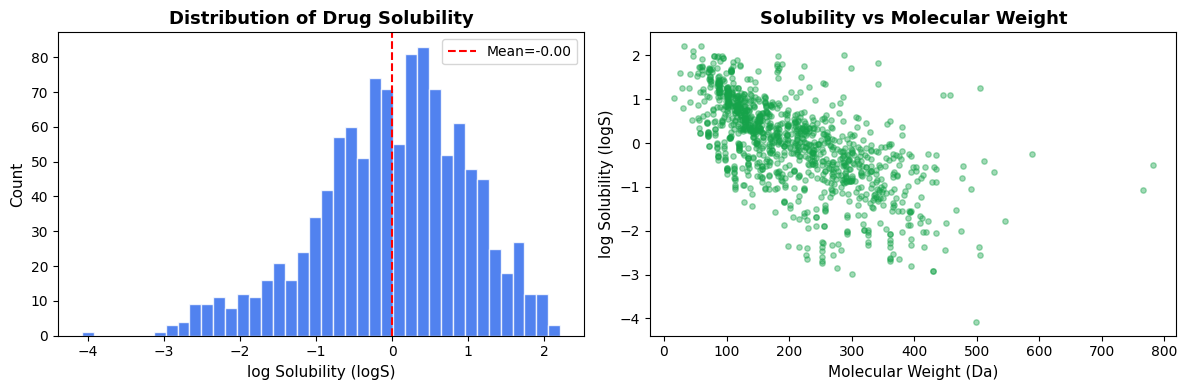

Saved data_distribution.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['logS'], bins=40, color='#2563eb', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('log Solubility (logS)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Distribution of Drug Solubility', fontsize=13, fontweight='bold')
axes[0].axvline(df['logS'].mean(), color='red', linestyle='--', label=f"Mean={df['logS'].mean():.2f}")
axes[0].legend()

# Molecular weight distribution
mw_list = []
for smi in df['smiles']:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mw_list.append(Descriptors.MolWt(mol))
    else:
        mw_list.append(0)

axes[1].scatter(mw_list, df['logS'], alpha=0.4, s=15, color='#16a34a')
axes[1].set_xlabel('Molecular Weight (Da)', fontsize=11)
axes[1].set_ylabel('log Solubility (logS)', fontsize=11)
axes[1].set_title('Solubility vs Molecular Weight', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('data_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved data_distribution.png")

 STEP 6: Convert Molecules to Graphs

In [18]:
print("\nConverting molecules to graphs...")

def mol_to_graph(smiles, y_val):
    """Convert a SMILES string to a PyTorch Geometric graph."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Atom (node) features
    atom_features = []
    for atom in mol.GetAtoms():
        features = [
            atom.GetAtomicNum(),              # atomic number
            atom.GetDegree(),                  # number of bonds
            atom.GetFormalCharge(),            # charge
            atom.GetNumRadicalElectrons(),     # radical electrons
            int(atom.GetHybridization()),      # hybridization
            int(atom.GetIsAromatic()),         # is aromatic
            atom.GetTotalNumHs(),              # H count
            atom.GetNumExplicitHs(),           # explicit H
            int(atom.IsInRing()),              # in ring
            Descriptors.MolLogP(Chem.MolFromSmiles(atom.GetSymbol())) if Chem.MolFromSmiles(atom.GetSymbol()) else 0,
        ]
        atom_features.append(features)

    x = torch.tensor(atom_features, dtype=torch.float)

    # Bond (edge) information
    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        # Undirected: add both directions
        edge_index.extend([[i, j], [j, i]])

        bond_features = [
            int(bond.GetBondTypeAsDouble()),
            int(bond.GetIsConjugated()),
            int(bond.IsInRing()),
        ]
        edge_attr.extend([bond_features, bond_features])

    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0, 3), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    y = torch.tensor([y_val], dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    return data

# Convert all molecules
graph_list = []
failed = 0
for idx, row in df.iterrows():
    graph = mol_to_graph(row['smiles'], row['logS'])
    if graph is not None:
        graph_list.append(graph)
    else:
        failed += 1
    if (idx + 1) % 200 == 0:
        print(f"  Processed {idx + 1}/{len(df)} molecules...")

print(f"\nConverted {len(graph_list)} molecules to graphs ({failed} failed)")
print(f"Example graph: {graph_list[0]}")
print(f"  Nodes (atoms): {graph_list[0].x.shape[0]}")
print(f"  Node features: {graph_list[0].x.shape[1]}")
print(f"  Edges (bonds): {graph_list[0].edge_index.shape[1]}")


Converting molecules to graphs...
  Processed 200/1128 molecules...
  Processed 400/1128 molecules...
  Processed 600/1128 molecules...
  Processed 800/1128 molecules...
  Processed 1000/1128 molecules...

Converted 1128 molecules to graphs (0 failed)
Example graph: Data(x=[32, 10], edge_index=[2, 68], edge_attr=[68, 3], y=[1])
  Nodes (atoms): 32
  Node features: 10
  Edges (bonds): 68


STEP 7: Split Data

In [19]:
train_data, temp_data = train_test_split(graph_list, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"\nData split:")
print(f"  Train: {len(train_data)} molecules")
print(f"  Val:   {len(val_data)} molecules")
print(f"  Test:  {len(test_data)} molecules")


Data split:
  Train: 902 molecules
  Val:   113 molecules
  Test:  113 molecules


STEP 8: Build GCN Model (Graph Convolutional Network)

In [20]:
class GCN_Solubility(nn.Module):
    """Graph Convolutional Network for molecular solubility prediction."""

    def __init__(self, num_features, hidden_dim=128):
        super(GCN_Solubility, self).__init__()

        # Graph convolution layers
        self.conv1 = GCNConv(num_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        # Batch normalization
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        # Fully connected layers
        self.fc1 = nn.Linear(hidden_dim * 2, 128)  # *2 for mean+max pool
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

        self.dropout = nn.Dropout(0.2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Graph convolutions with skip connections
        x1 = F.relu(self.bn1(self.conv1(x, edge_index)))
        x2 = F.relu(self.bn2(self.conv2(x1, edge_index)))
        x3 = F.relu(self.bn3(self.conv3(x2, edge_index)))

        # Skip connection
        x = x2 + x3

        # Global pooling (mean + max = richer representation)
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)

        # Prediction head
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x.squeeze()

 STEP 9: Build GAT Model (Graph Attention Network)

In [22]:
class GAT_Solubility(nn.Module):
    """Graph Attention Network — uses attention to weigh neighbor importance."""

    def __init__(self, num_features, hidden_dim=128, heads=4):
        super(GAT_Solubility, self).__init__()

        self.conv1 = GATConv(num_features, hidden_dim, heads=heads, dropout=0.2)
        self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, dropout=0.2)

        self.bn1 = nn.BatchNorm1d(hidden_dim * heads)
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        self.fc1 = nn.Linear(hidden_dim * 2, 128)
        self.fc2 = nn.Linear(128, 1)
        self.dropout = nn.Dropout(0.2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.elu(self.bn2(self.conv2(x, edge_index)))

        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x.squeeze()

STEP 10: Training Function

In [24]:
def train_model(model, train_loader, val_loader, model_name, epochs=150):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)
    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    print(f"\nTraining {model_name}...")
    print("-" * 50)

    for epoch in range(epochs):
        # Train
        model.train()
        total_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            pred = model(batch)
            loss = criterion(pred, batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch.num_graphs

        train_loss = total_loss / len(train_loader.dataset)

        # Validate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                pred = model(batch)
                val_loss += criterion(pred, batch.y).item() * batch.num_graphs

        val_loss = val_loss / len(val_loader.dataset)
        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'best_{model_name}.pt')

        if (epoch + 1) % 25 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    print(f"Best val loss: {best_val_loss:.4f}")
    return train_losses, val_losses

STEP 11: Train Both Models

In [25]:
num_features = graph_list[0].x.shape[1]

# Model 1: GCN
gcn_model = GCN_Solubility(num_features).to(device)
print(f"\nGCN parameters: {sum(p.numel() for p in gcn_model.parameters()):,}")
gcn_train_loss, gcn_val_loss = train_model(gcn_model, train_loader, val_loader, "GCN")

# Model 2: GAT
gat_model = GAT_Solubility(num_features).to(device)
print(f"\nGAT parameters: {sum(p.numel() for p in gat_model.parameters()):,}")
gat_train_loss, gat_val_loss = train_model(gat_model, train_loader, val_loader, "GAT")


GCN parameters: 76,417

Training GCN...
--------------------------------------------------
Epoch  25/150 | Train Loss: 0.1400 | Val Loss: 0.1088
Epoch  50/150 | Train Loss: 0.1177 | Val Loss: 0.1229
Epoch  75/150 | Train Loss: 0.1258 | Val Loss: 0.1100
Epoch 100/150 | Train Loss: 0.0831 | Val Loss: 0.0862
Epoch 125/150 | Train Loss: 0.0622 | Val Loss: 0.0708
Epoch 150/150 | Train Loss: 0.0451 | Val Loss: 0.0855
Best val loss: 0.0708

GAT parameters: 106,881

Training GAT...
--------------------------------------------------
Epoch  25/150 | Train Loss: 0.2219 | Val Loss: 0.1801
Epoch  50/150 | Train Loss: 0.2090 | Val Loss: 0.3145
Epoch  75/150 | Train Loss: 0.1480 | Val Loss: 0.2973
Epoch 100/150 | Train Loss: 0.1324 | Val Loss: 0.3393
Epoch 125/150 | Train Loss: 0.1296 | Val Loss: 0.2580
Epoch 150/150 | Train Loss: 0.1149 | Val Loss: 0.2673
Best val loss: 0.1488


STEP 12: Evaluate on Test Set

In [26]:
def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            pred = model(batch)
            all_preds.extend(pred.cpu().numpy())
            all_true.extend(batch.y.cpu().numpy())

    all_preds = np.array(all_preds)
    all_true = np.array(all_true)

    rmse = np.sqrt(mean_squared_error(all_true, all_preds))
    mae = mean_absolute_error(all_true, all_preds)
    r2 = r2_score(all_true, all_preds)

    print(f"\n{'='*50}")
    print(f"{model_name} TEST RESULTS")
    print(f"{'='*50}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"MAE:   {mae:.4f}")
    print(f"R²:    {r2:.4f}")

    return all_true, all_preds, rmse, mae, r2

# Load best models and evaluate
gcn_model.load_state_dict(torch.load('best_GCN.pt'))
gat_model.load_state_dict(torch.load('best_GAT.pt'))

gcn_true, gcn_preds, gcn_rmse, gcn_mae, gcn_r2 = evaluate_model(gcn_model, test_loader, "GCN")
gat_true, gat_preds, gat_rmse, gat_mae, gat_r2 = evaluate_model(gat_model, test_loader, "GAT")



GCN TEST RESULTS
RMSE:  0.3096
MAE:   0.2229
R²:    0.9012

GAT TEST RESULTS
RMSE:  0.4663
MAE:   0.3477
R²:    0.7758


STEP 13: Plot Training Curves

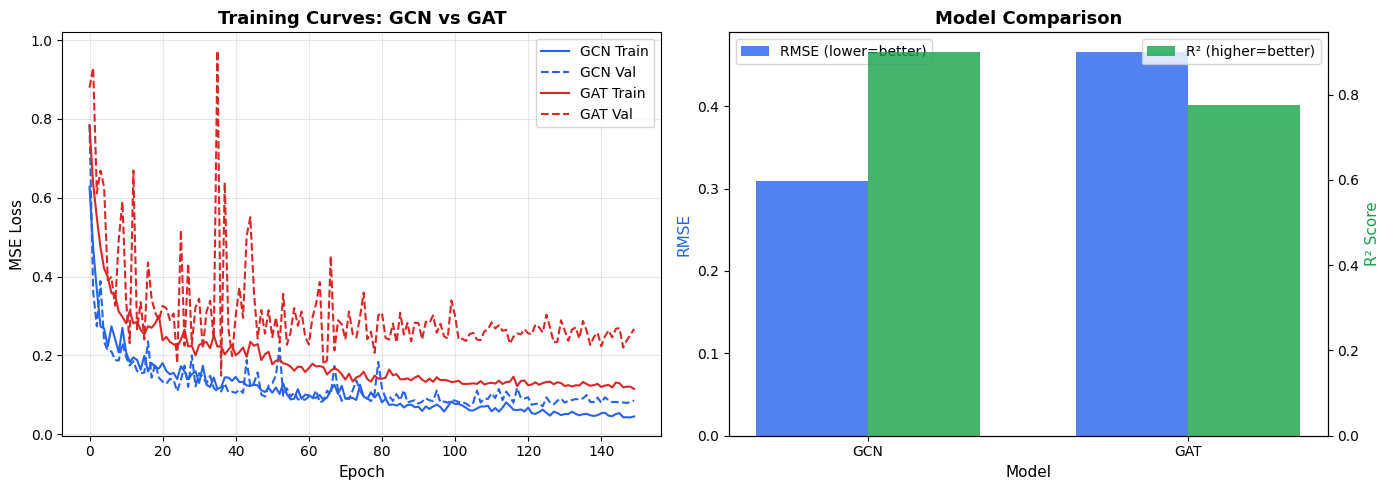

Saved training_comparison.png


In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(gcn_train_loss, label='GCN Train', color='#2563eb', linewidth=1.5)
ax1.plot(gcn_val_loss, label='GCN Val', color='#2563eb', linewidth=1.5, linestyle='--')
ax1.plot(gat_train_loss, label='GAT Train', color='#dc2626', linewidth=1.5)
ax1.plot(gat_val_loss, label='GAT Val', color='#dc2626', linewidth=1.5, linestyle='--')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('MSE Loss', fontsize=11)
ax1.set_title('Training Curves: GCN vs GAT', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Model comparison bar chart
models = ['GCN', 'GAT']
rmse_vals = [gcn_rmse, gat_rmse]
r2_vals = [gcn_r2, gat_r2]
x = np.arange(len(models))
width = 0.35

bars1 = ax2.bar(x - width/2, rmse_vals, width, label='RMSE (lower=better)', color='#2563eb', alpha=0.8)
ax2_twin = ax2.twinx()
bars2 = ax2_twin.bar(x + width/2, r2_vals, width, label='R² (higher=better)', color='#16a34a', alpha=0.8)

ax2.set_xlabel('Model', fontsize=11)
ax2.set_ylabel('RMSE', fontsize=11, color='#2563eb')
ax2_twin.set_ylabel('R² Score', fontsize=11, color='#16a34a')
ax2.set_title('Model Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved training_comparison.png")

STEP 14: Predicted vs Actual Scatter Plot

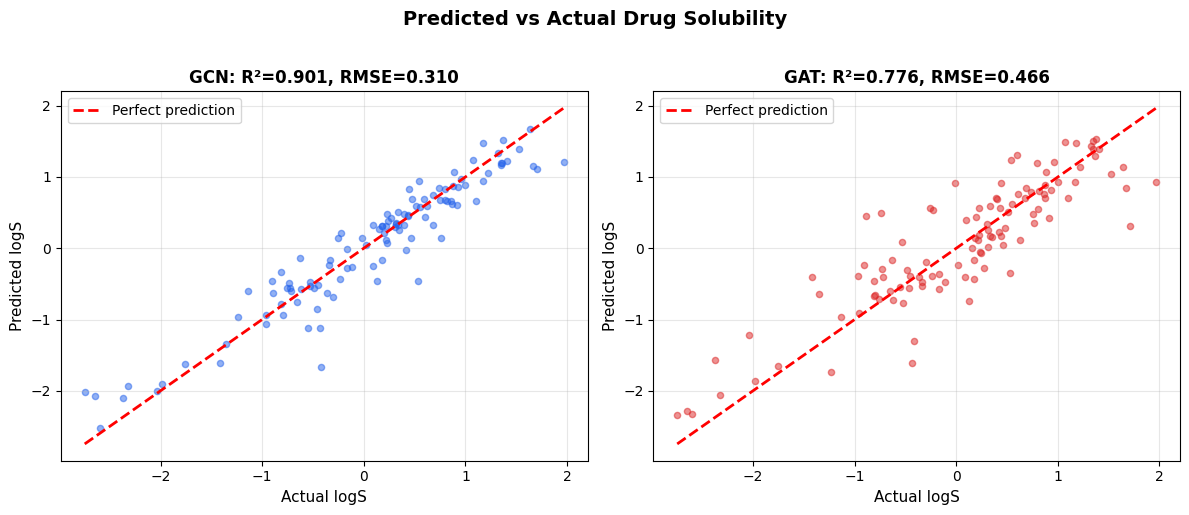

Saved prediction_scatter.png


In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# GCN scatter
ax1.scatter(gcn_true, gcn_preds, alpha=0.5, s=20, color='#2563eb')
ax1.plot([min(gcn_true), max(gcn_true)], [min(gcn_true), max(gcn_true)],
         'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual logS', fontsize=11)
ax1.set_ylabel('Predicted logS', fontsize=11)
ax1.set_title(f'GCN: R²={gcn_r2:.3f}, RMSE={gcn_rmse:.3f}', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# GAT scatter
ax2.scatter(gat_true, gat_preds, alpha=0.5, s=20, color='#dc2626')
ax2.plot([min(gat_true), max(gat_true)], [min(gat_true), max(gat_true)],
         'r--', linewidth=2, label='Perfect prediction')
ax2.set_xlabel('Actual logS', fontsize=11)
ax2.set_ylabel('Predicted logS', fontsize=11)
ax2.set_title(f'GAT: R²={gat_r2:.3f}, RMSE={gat_rmse:.3f}', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Predicted vs Actual Drug Solubility', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('prediction_scatter.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved prediction_scatter.png")

STEP 15: Error Distribution Analysis

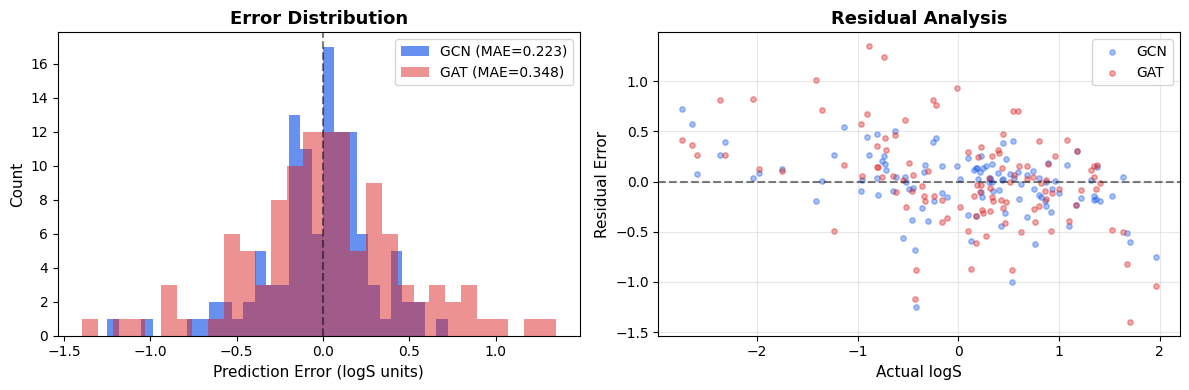

Saved error_analysis.png


In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

gcn_errors = gcn_preds - gcn_true
gat_errors = gat_preds - gat_true

ax1.hist(gcn_errors, bins=30, color='#2563eb', alpha=0.7, label=f'GCN (MAE={gcn_mae:.3f})')
ax1.hist(gat_errors, bins=30, color='#dc2626', alpha=0.5, label=f'GAT (MAE={gat_mae:.3f})')
ax1.set_xlabel('Prediction Error (logS units)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Error Distribution', fontsize=13, fontweight='bold')
ax1.axvline(0, color='black', linestyle='--', alpha=0.5)
ax1.legend()

# Residual plot
ax2.scatter(gcn_true, gcn_errors, alpha=0.4, s=15, color='#2563eb', label='GCN')
ax2.scatter(gat_true, gat_errors, alpha=0.4, s=15, color='#dc2626', label='GAT')
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Actual logS', fontsize=11)
ax2.set_ylabel('Residual Error', fontsize=11)
ax2.set_title('Residual Analysis', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved error_analysis.png")

STEP 16: Summary

In [30]:
print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)
print(f"Dataset: ESOL (Estimated Solubility) — {len(graph_list)} drug molecules")
print(f"Task: Predict log Solubility (logS) from molecular graph")
print(f"Node features: {num_features} per atom")
print(f"")
print(f"GCN (Graph Convolutional Network):")
print(f"  RMSE: {gcn_rmse:.4f} | MAE: {gcn_mae:.4f} | R²: {gcn_r2:.4f}")
print(f"")
print(f"GAT (Graph Attention Network):")
print(f"  RMSE: {gat_rmse:.4f} | MAE: {gat_mae:.4f} | R²: {gat_r2:.4f}")
print(f"")
print(f"Files saved:")
print(f"  - sample_molecules.png")
print(f"  - data_distribution.png")
print(f"  - training_comparison.png")
print(f"  - prediction_scatter.png")
print(f"  - error_analysis.png")
print(f"  - best_GCN.pt / best_GAT.pt")
print(f"")
print(f"Author: Pradip Palekar (MT25215)")
print(f"IIIT Delhi, M.Tech Computational Biology")
print("=" * 60)



PROJECT SUMMARY
Dataset: ESOL (Estimated Solubility) — 1128 drug molecules
Task: Predict log Solubility (logS) from molecular graph
Node features: 10 per atom

GCN (Graph Convolutional Network):
  RMSE: 0.3096 | MAE: 0.2229 | R²: 0.9012

GAT (Graph Attention Network):
  RMSE: 0.4663 | MAE: 0.3477 | R²: 0.7758

Files saved:
  - sample_molecules.png
  - data_distribution.png
  - training_comparison.png
  - prediction_scatter.png
  - error_analysis.png
  - best_GCN.pt / best_GAT.pt

Author: Pradip Palekar (MT25215)
IIIT Delhi, M.Tech Computational Biology
